# Data Science Capstone Project

# Machine Learning-Based Insider Threat Detection Using Employee Behavioral Data

## Machine Learning Modeling [(Previous Step: EDA)](01_eda.ipynb)

## Objective

This notebook performs the core machine learning processes, from the encoding, to the model training to model evaluation and improvements.

### Step 1: Import Libraries

In [48]:
# Regular EDA (exploratory data analysis) and plotting libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Models from Scikit-Learn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Data Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Model Evaluations
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay,roc_curve, roc_auc_score

### Step 2: Load Data

In [2]:
df = pd.read_csv("insider_threat_clean_dataset.csv")
df

,employee_department,employee_campus,employee_position,employee_seniority_years,is_contractor,employee_classification,has_foreign_citizenship,has_criminal_record,has_medical_history,employee_origin_country,...,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend,is_malicious
0,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,4,0,0,0.0,0,1,1,0,1,0
1,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
2,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,2,0,0,0.0,0,1,1,0,0,0
3,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,1,1,0,0,0
4,Engineering Department,Campus C,Design Engineer,22,0,2,0,0,0,Georgia,...,0,0,0,0.0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
118609,Operations and Manufacturing,Campus B,Procurement Officer,2,0,1,0,0,0,Israel,...,0,0,0,0.0,0,0,0,0,0,0
118610,Operations and Manufacturing,Campus B,Procurement Officer,2,0,1,0,0,0,Israel,...,0,0,0,0.0,0,2,1,0,0,0
118611,Operations and Manufacturing,Campus B,Procurement Officer,2,0,1,0,0,0,Israel,...,0,0,0,0.0,0,2,1,0,0,0
118612,Operations and Manufacturing,Campus B,Procurement Officer,2,0,1,0,0,0,Israel,...,0,0,0,0.0,0,0,0,0,0,0


### Step 3: Feature Selection

In [3]:
features = [
    "employee_seniority_years",
    "is_contractor",
    "total_printed_pages",
    "num_printed_pages_off_hours",
    "total_files_burned",
    "burned_from_other",
    "is_abroad",
    "trip_day_number",
    "hostility_country_level",
    "num_entries",
    "num_unique_campus",
    "late_exit_flag",
    "entry_during_weekend"
]

X = df[features]

y = df["is_malicious"]

##### Making sure all the data types are numerical

In [4]:
X.dtypes

employee_seniority_years         int64
is_contractor                    int64
total_printed_pages              int64
num_printed_pages_off_hours      int64
total_files_burned               int64
burned_from_other                int64
is_abroad                        int64
trip_day_number                float64
hostility_country_level          int64
num_entries                      int64
num_unique_campus                int64
late_exit_flag                   int64
entry_during_weekend             int64
dtype: object

### Step 4: Train/Test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [6]:
X_train.head()

,employee_seniority_years,is_contractor,total_printed_pages,num_printed_pages_off_hours,total_files_burned,burned_from_other,is_abroad,trip_day_number,hostility_country_level,num_entries,num_unique_campus,late_exit_flag,entry_during_weekend
46998,26,0,4,0,0,0,0,0.0,0,2,1,0,0
57121,0,0,19,0,0,0,0,0.0,0,0,0,0,0
72725,8,0,0,0,27,0,0,0.0,0,1,1,0,0
10770,9,1,0,0,38,0,0,0.0,0,1,1,0,0
109213,21,0,41,0,0,0,0,0.0,0,0,0,0,0


In [7]:
X_train.shape

(94891, 13)

In [8]:
X_test.shape

(23723, 13)

### Step 4: Model training

#### Model Selection
Three classification algorithms were selected:

**1. Logistic Regression:**
Logistic Regression was used as a relatively interpretable baseline classification model. Its inclusion provides a useful reference point for comparing a linear model against non-linear approaches.

**2. K-Nearest Neighbors:**
KNN was selected to evaluate whether similarity between observations could effectively distinguish malicious behavioral records from non-malicious records.

**3. Random Forest:**
Random Forest was selected because it can capture non-linear relationships and interactions among variables and can provide feature-importance estimates.


#### Logistic Regression

##### Data Preprocessing

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### Actual model training

In [10]:
log_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

##### Making predictions

In [11]:
y_pred_log = log_model.predict(X_test_scaled)

In [12]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8741727437507903
Precision: 0.25889328063241107
Recall: 0.7180892717306187
F1 Score: 0.3805768831707823

Confusion Matrix:
[[19821  2625]
 [  360   917]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.88      0.93     22446
           1       0.26      0.72      0.38      1277

    accuracy                           0.87     23723
   macro avg       0.62      0.80      0.66     23723
weighted avg       0.94      0.87      0.90     23723



In [13]:
log_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred_log),
    "Precision": precision_score(y_test, y_pred_log),
    "Recall": recall_score(y_test, y_pred_log),
    "F1 Score": f1_score(y_test, y_pred_log)
}

print(log_results)

{'Model': 'Logistic Regression', 'Accuracy': 0.8741727437507903, 'Precision': 0.25889328063241107, 'Recall': 0.7180892717306187, 'F1 Score': 0.3805768831707823}


#### KNeighbors Classifier

In [14]:
kmodel = KNeighborsClassifier(n_neighbors = 5)

kmodel.fit(X_train_scaled,y_train)

y_pred_knn = kmodel.predict(X_test_scaled)

In [15]:
knn_results = {
    "Model": "K-Nearest Neighbors",
    "Accuracy": accuracy_score(y_test, y_pred_knn),
    "Precision": precision_score(y_test, y_pred_knn),
    "Recall": recall_score(y_test, y_pred_knn),
    "F1 Score": f1_score(y_test, y_pred_knn)
}

print(knn_results)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

{'Model': 'K-Nearest Neighbors', 'Accuracy': 0.9680057328331155, 'Precision': 0.7815217391304348, 'Recall': 0.5630383711824589, 'F1 Score': 0.6545289030496131}

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     22446
           1       0.78      0.56      0.65      1277

    accuracy                           0.97     23723
   macro avg       0.88      0.78      0.82     23723
weighted avg       0.97      0.97      0.97     23723


Confusion Matrix:
[[22245   201]
 [  558   719]]


#### Random Forest Classifier

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train,y_train)

y_pred_rf = rf_model.predict(X_test)

In [17]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, y_pred_rf),
    "Precision": precision_score(y_test, y_pred_rf),
    "Recall": recall_score(y_test, y_pred_rf),
    "F1 Score": f1_score(y_test, y_pred_rf)
}

print(rf_results)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

{'Model': 'Random Forest', 'Accuracy': 0.9107617080470429, 'Precision': 0.33783783783783783, 'Recall': 0.6851996867658575, 'F1 Score': 0.4525471942073959}

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95     22446
           1       0.34      0.69      0.45      1277

    accuracy                           0.91     23723
   macro avg       0.66      0.80      0.70     23723
weighted avg       0.95      0.91      0.92     23723


Confusion Matrix:
[[20731  1715]
 [  402   875]]


### Hyperparameter Tuning and Cross Validation

#### Pipeline creation for hyperparameter tuning
This is a better way to use the unscaled X and y train variables in the two out of three algorithms that need them scaled

In [18]:
log_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

In [19]:
kmodel_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", KNeighborsClassifier())
])

In [20]:
rf_pipeline = Pipeline([
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

##### Cross validation method creation

In [22]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

We're using StratifiedKFold because the target is imbalanced

#### Hyper parameter tuning using RandomSearchCV

In [23]:
log_param_dist = {
    "model__C": np.logspace(-3, 2, 20),
    "model__solver": ["liblinear", "lbfgs"]
}

log_random = RandomizedSearchCV(
    log_pipeline,
    param_distributions=log_param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

log_random.fit(X_train, y_train)

print("Best parameters:", log_random.best_params_)
print("Best CV F1:", log_random.best_score_)

Best parameters: {'model__solver': 'lbfgs', 'model__C': np.float64(0.06951927961775606)}
Best CV F1: 0.3850406193121634


In [29]:
kmodel_param_dist = {
    "model__n_neighbors": range(3, 21),
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

kmodel_random = RandomizedSearchCV(
    kmodel_pipeline,
    param_distributions=kmodel_param_dist,
    n_iter=10,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

kmodel_random.fit(X_train, y_train)

print("Best parameters:", kmodel_random.best_params_)
print("Best CV F1:", kmodel_random.best_score_)

Best parameters: {'model__weights': 'uniform', 'model__p': 2, 'model__n_neighbors': 5}
Best CV F1: 0.6697470333896824


In [30]:
rf_param_dist = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

rf_random = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1
)

rf_random.fit(X_train, y_train)

print("Best parameters:", rf_random.best_params_)
print("Best CV F1:", rf_random.best_score_)

Best parameters: {'model__n_estimators': 500, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best CV F1: 0.5888085685567491


##### Hyper parameter tuning using GridSearchCV

In [31]:
log_grid = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__solver": ["liblinear", "lbfgs"]
}

log_grid_search = GridSearchCV(
    log_pipeline,
    param_grid=log_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

log_grid_search.fit(X_train, y_train)

print("Best parameters:", log_grid_search.best_params_)
print("Best CV F1:", log_grid_search.best_score_)

Best parameters: {'model__C': 0.01, 'model__solver': 'lbfgs'}
Best CV F1: 0.38588087299573415


In [25]:
kmodel_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 13, 15],
    "model__weights": ["uniform", "distance"],
    "model__p": [1, 2]
}

kmodel_grid_search = GridSearchCV(
    kmodel_pipeline,
    param_grid=kmodel_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

kmodel_grid_search.fit(X_train, y_train)

print("Best parameters:", kmodel_grid_search.best_params_)
print("Best CV F1:", kmodel_grid_search.best_score_)

Best parameters: {'model__n_neighbors': 9, 'model__p': 1, 'model__weights': 'uniform'}
Best CV F1: 0.6700873155951028


In [26]:
rf_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [10, 20, 30],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt", "log2"]
}

rf_grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=rf_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1
)

rf_grid_search.fit(X_train, y_train)

print("Best parameters:", rf_grid_search.best_params_)
print("Best CV F1:", rf_grid_search.best_score_)

Best parameters: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best CV F1: 0.5856161409460193


### Final tuned models

In [42]:
# Grid Search CV
best_log = log_grid_search.best_estimator_
best_kmodel = kmodel_grid_search.best_estimator_
best_rf = rf_grid_search.best_estimator_

print(f"{best_log} {best_kmodel}  {best_rf}")

Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, random_state=42))]) Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=9, p=1))])  Pipeline(steps=[('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=10,
                                        n_estimators=300, n_jobs=-1,
                                        random_state=42))])


### Performance evaluation

#### Evaluation Metrics

The following metrics were evaluated:

* **Accuracy**: The proportion of all predictions that were correctly classified.
* **Precision**: The proportion of records predicted as malicious that were actually malicious. High precision minimizes false positives, reducing the number of legitimate users incorrectly flagged.
* **Recall**: The proportion of actual malicious records correctly identified. High recall is critical in security applications to minimize false negatives, where missed malicious activity represents significant risk.
* **F1-Score**: The harmonic mean of precision and recall, balancing both metrics into a single score.
* **ROC-AUC**: Evaluates the model's ability to discriminate between classes across varying classification thresholds.
* **PR-AUC (Precision-Recall AUC)**: Focuses directly on positive-class performance, providing a more reliable evaluation metric for imbalanced datasets.


In [44]:
y_pred_log_tuned = best_log.predict(X_test)
y_pred_kmodel_tuned = best_kmodel.predict(X_test)
y_pred_rf_tuned = best_rf.predict(X_test)

In [46]:
tuned_results = []

models = {
    "Logistic Regression": (best_log, y_pred_log_tuned),
    "KNN": (best_kmodel, y_pred_kmodel_tuned),
    "Random Forest": (best_rf, y_pred_rf_tuned)
}

for name, (model, predictions) in models.items():

    tuned_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions)
    })

tuned_results_df = pd.DataFrame(tuned_results)

print(tuned_results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.874552   0.259280  0.716523  0.380774
1                  KNN  0.968343   0.807963  0.540329  0.647583
2        Random Forest  0.939342   0.461095  0.751762  0.571599


#### ROC AUC calculations

In [49]:
# Predicted probabilities for the malicious class
y_prob_log = best_log.predict_proba(X_test)[:, 1]
y_prob_knn = best_kmodel.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# ROC curves
fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

# ROC-AUC
auc_log = roc_auc_score(y_test, y_prob_log)
auc_knn = roc_auc_score(y_test, y_prob_knn)
auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Logistic Regression ROC-AUC:", auc_log)
print("KNN ROC-AUC:", auc_knn)
print("Random Forest ROC-AUC:", auc_rf)

Logistic Regression ROC-AUC: 0.8735865232566165
KNN ROC-AUC: 0.8679552931734675
Random Forest ROC-AUC: 0.920983456964251


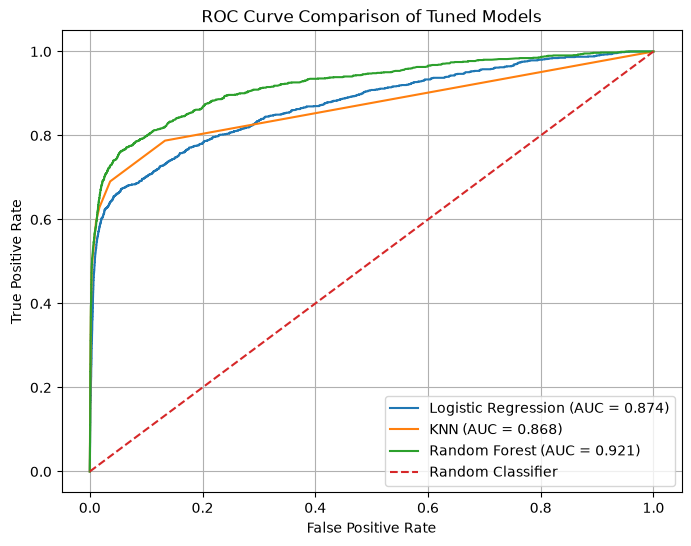

In [50]:
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_log,
    tpr_log,
    label=f"Logistic Regression (AUC = {auc_log:.3f})"
)

plt.plot(
    fpr_knn,
    tpr_knn,
    label=f"KNN (AUC = {auc_knn:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {auc_rf:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison of Tuned Models")
plt.legend()
plt.grid()

plt.show()


Logistic Regression
[[19832  2614]
 [  362   915]]


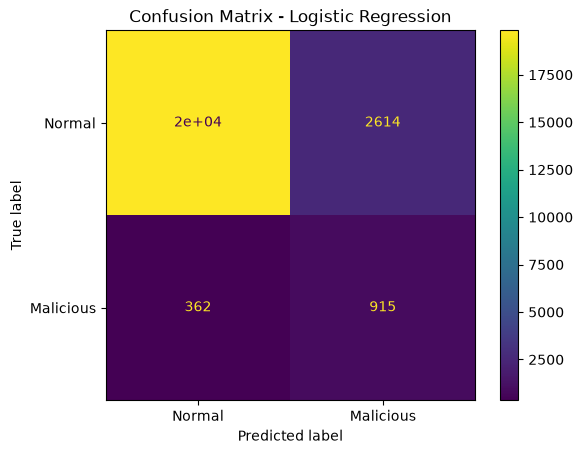


KNN
[[22282   164]
 [  587   690]]


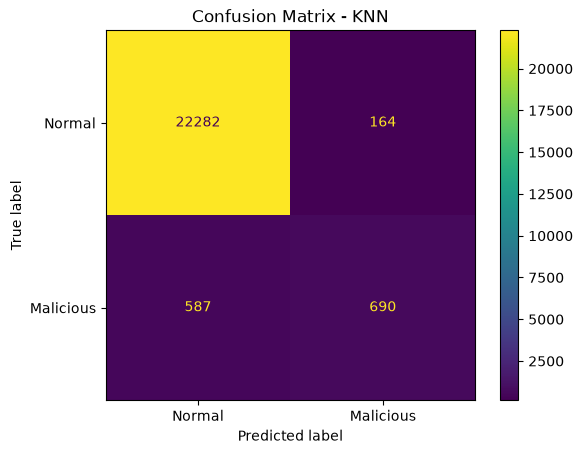


Random Forest
[[21324  1122]
 [  317   960]]


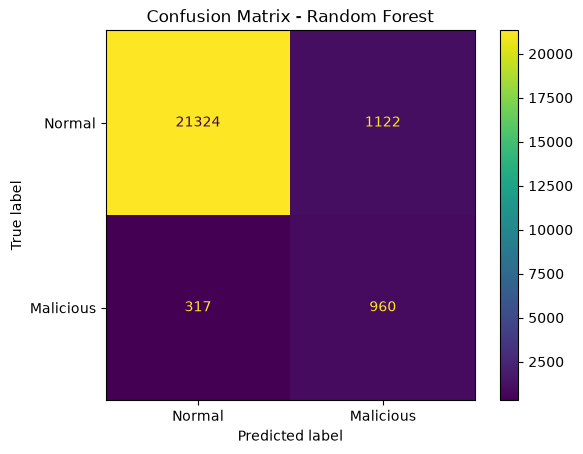

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


models = {
    "Logistic Regression": best_log,
    "KNN": best_kmodel,
    "Random Forest": best_rf
}

for name, model in models.items():
    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{name}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Malicious"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()

In [52]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Random Forest"
    ],
    "Accuracy": [
        0.874552,
        0.968343,
        0.939342
    ],
    "Precision": [
        0.259280,
        0.807963,
        0.461095
    ],
    "Recall": [
        0.716523,
        0.540329,
        0.751762
    ],
    "F1 Score": [
        0.380774,
        0.647583,
        0.571599
    ],
    "ROC-AUC": [
        auc_log,
        auc_knn,
        auc_rf
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.874552,0.259280,0.716523,0.380774,0.873587
1,KNN,0.968343,0.807963,0.540329,0.647583,0.867955
2,Random Forest,0.939342,0.461095,0.751762,0.571599,0.920983


In [53]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.named_steps["model"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
4,total_files_burned,0.432694
2,total_printed_pages,0.212060
10,num_unique_campus,0.083891
3,num_printed_pages_off_hours,0.080025
5,burned_from_other,0.052289
9,num_entries,0.050652
12,entry_during_weekend,0.027352
0,employee_seniority_years,0.024467
8,hostility_country_level,0.020947
7,trip_day_number,0.007163


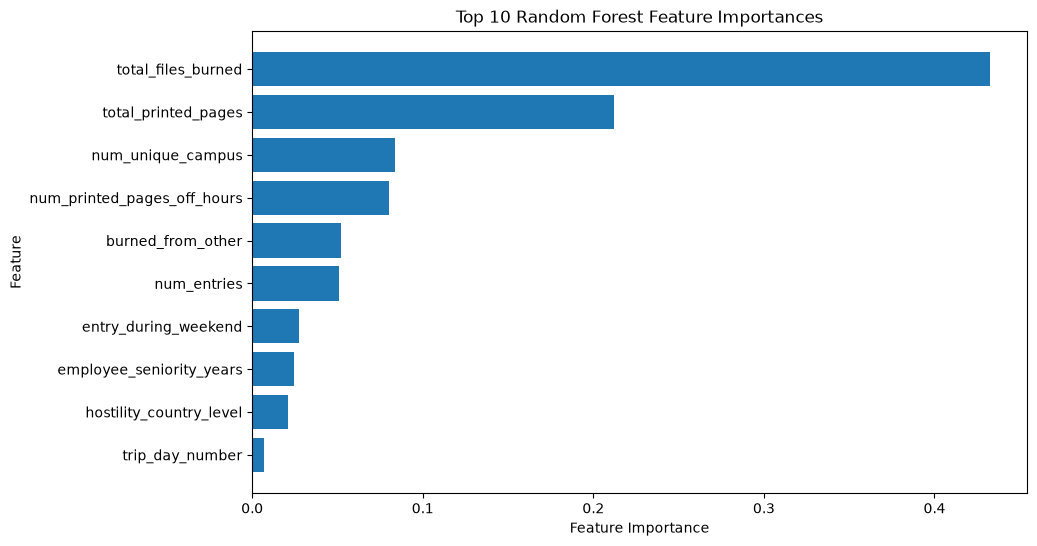

In [54]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.show()

In [56]:
from sklearn.metrics import precision_recall_curve, average_precision_score


# Predicted probabilities
y_prob_log = best_log.predict_proba(X_test)[:, 1]
y_prob_knn = best_kmodel.predict_proba(X_test)[:, 1]
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# Precision-Recall curves
precision_log, recall_log, _ = precision_recall_curve(y_test, y_prob_log)
precision_knn, recall_knn, _ = precision_recall_curve(y_test, y_prob_knn)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)

# PR-AUC / Average Precision
ap_log = average_precision_score(y_test, y_prob_log)
ap_knn = average_precision_score(y_test, y_prob_knn)
ap_rf = average_precision_score(y_test, y_prob_rf)

print("Logistic Regression PR-AUC:", ap_log)
print("KNN PR-AUC:", ap_knn)
print("Random Forest PR-AUC:", ap_rf)

Logistic Regression PR-AUC: 0.5814024516729458
KNN PR-AUC: 0.6218790013149771
Random Forest PR-AUC: 0.6861388491176101


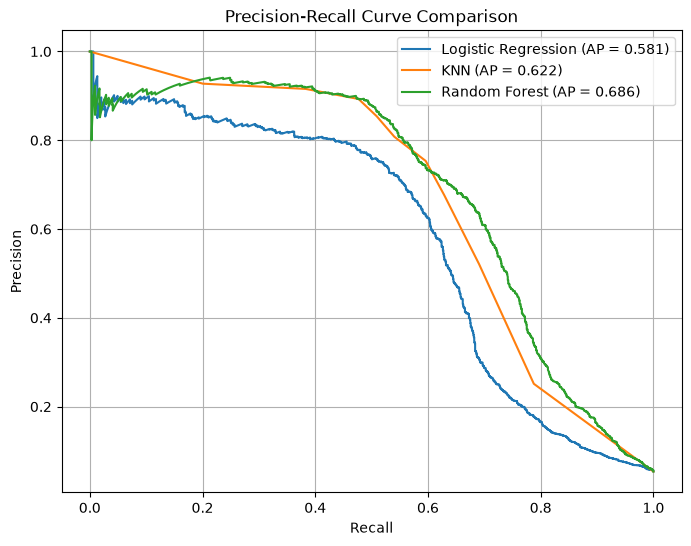

In [57]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_log,
    precision_log,
    label=f"Logistic Regression (AP = {ap_log:.3f})"
)

plt.plot(
    recall_knn,
    precision_knn,
    label=f"KNN (AP = {ap_knn:.3f})"
)

plt.plot(
    recall_rf,
    precision_rf,
    label=f"Random Forest (AP = {ap_rf:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison")
plt.legend()
plt.grid()

plt.show()

In [58]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

perm_results = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean
})

perm_results = perm_results.sort_values(
    by="Importance",
    ascending=False
)

perm_results

,Feature,Importance
4,total_files_burned,0.234390
2,total_printed_pages,0.081028
10,num_unique_campus,0.064606
9,num_entries,0.043756
3,num_printed_pages_off_hours,0.042295
5,burned_from_other,0.024614
8,hostility_country_level,0.010024
0,employee_seniority_years,0.009681
1,is_contractor,0.002747
12,entry_during_weekend,0.001279


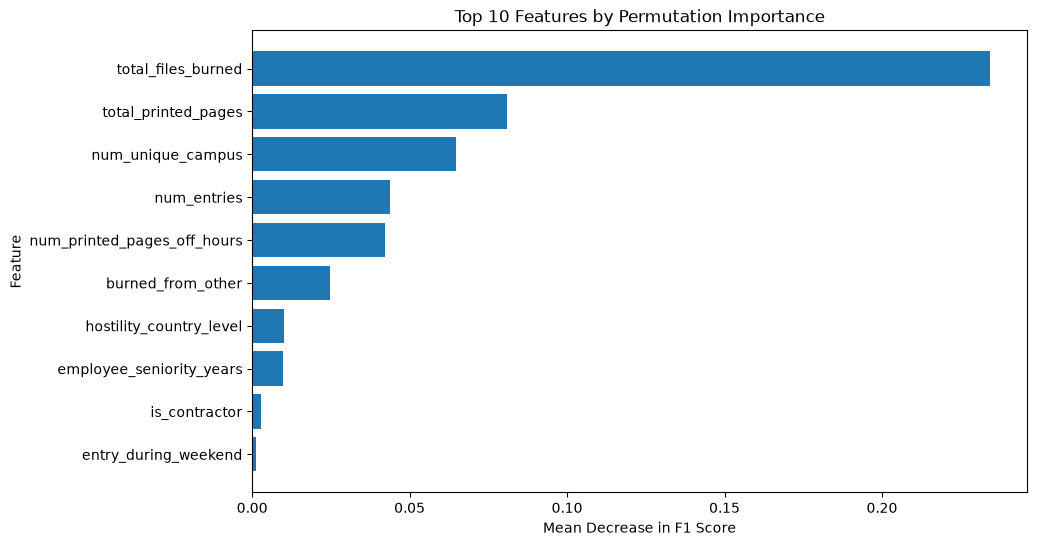

In [59]:
top_perm = perm_results.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_perm["Feature"][::-1],
    top_perm["Importance"][::-1]
)

plt.xlabel("Mean Decrease in F1 Score")
plt.ylabel("Feature")
plt.title("Top 10 Features by Permutation Importance")

plt.show()

#### Saving the optimised models and results

In [60]:
import joblib

joblib.dump(best_log, "logistic_regression_model.pkl")
joblib.dump(best_kmodel, "knn_model.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")

print("Models saved successfully.")

Models saved successfully.


In [61]:
joblib.dump(list(X_train.columns), "feature_names.pkl")

print("Feature names saved successfully.")

Feature names saved successfully.


In [62]:
final_results.to_csv("model_evaluation_results.csv", index=False)

print("Evaluation results saved successfully.")

Evaluation results saved successfully.


In [63]:
feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

perm_results.to_csv(
    "permutation_importance.csv",
    index=False
)

print("Feature importance results saved successfully.")

Feature importance results saved successfully.


## Discussion

### Experimental Results & Model Evaluation

The experimental results demonstrate that machine learning can identify useful patterns within synthetic behavioral data. However, the findings highlight the critical importance of aligning evaluation criteria with specific operational security objectives.

* **K-Nearest Neighbors (KNN)**
  * **Strengths:** Achieved the highest precision and F1-score, yielding a low false-positive rate. Alerts generated are highly reliable and likely to correspond to actual malicious records.
  * **Weaknesses:** Missed **587 malicious observations** (false negatives), creating significant risk where undetected threats could persist without investigation.

* **Random Forest**
  * **Strengths:** Achieved the highest recall at **75.18%** (detecting **960 malicious observations**), alongside the strongest **ROC-AUC** and **PR-AUC** scores.
  * **Trade-off:** Generated **1,122 false positives**, increasing analyst alert fatigue.

* **Logistic Regression**
  * Demonstrated a competitive recall of **71.65%**, but suffered from low precision at **25.93%**, leading to a large volume of false-positive alerts.

---

> **Operational Takeaway:**  
> Selection depends on security posture: **Random Forest** is preferable when the priority is threat discovery and minimizing missed attacks, whereas **KNN** is better suited for reducing alert fatigue. These results underscore why accuracy-only evaluation is insufficient for imbalanced cybersecurity workloads.

### Privacy & Ethical Considerations

Monitoring employee behavioral telemetry establishes an inherent conflict between defensive visibility and individual privacy. In accordance with the **NIST Privacy Framework**, privacy risks must be managed alongside enterprise threats. 

To maintain compliance with the principle of **data minimization**, this project deliberately excluded non-essential sensitive attributes, reducing inference generation while preserving predictive utility. 

#### Recommended Deployment Safeguards
1. **Purpose Limitation:** Explicitly defined monitoring criteria and strict access boundaries.
2. **Telemetry Restraint:** Restricting data ingestion exclusively to authorized behavioral metrics.
3. **Data Protection:** Encryption, secure storage, and clear data lifecycle/deletion policies.
4. **Human-in-the-Loop Validation:** Mandatory human triage for flagged anomalies; the model must not execute punitive, disciplinary, or termination actions automatically.
5. **Accountability & Due Process:** Continuous auditing for algorithmic bias and clear avenues to contest flagged classifications.


### IT-Risk Perspective

Machine learning operates here as a detective control that enhances security operational capability while introducing unique operational vulnerabilities.

* **Detective Benefits:**
  * *Risk Identification & Prioritization:* Maps observed behaviors to threat vectors and ranks events by urgency.
  * *Continuous Telemetry Auditing:* Scales log evaluation beyond manual human capacity.
  * *Incident Support & Policy Tuning:* Surfaces behavioral patterns to accelerate forensic root-cause analysis and inform policy adjustments.

* **Associated Risks:**
  * *Classification Errors:* False alarms inducing SOC fatigue; missed malicious actions allowing adversary dwell time.
  * *Model Degradation:* Data and concept drift over time.
  * *Trust & Interpretability:* Explainability deficits and over-reliance on automated indicators.
  * *Security & Misuse:* Adversarial feature manipulation and improper operational deployment for HR actions.

Sustainable deployment therefore demands a joint framework pairing technical safeguards with enterprise risk governance.

## Recommendations

To deploy machine learning responsibly for insider-threat detection, organizations should focus on four core priorities:

* **Human-in-the-Loop Triage:** Treat outputs strictly as decision-support indicators, never as autonomous justification for disciplinary action.
* **Risk-Aligned Selection:** Tune thresholds based on organizational tolerance for false alarms (KNN) versus missed threats (Random Forest).
* **Data Minimization:** Restrict ingested features to essential behavioral telemetry, deliberately omitting sensitive personal data.
* **Continuous Governance:** Regularly audit models for concept drift, performance decay, and demographic bias.

> **Future Research Priorities:** Benchmark against real-world enterprise telemetry, incorporate Explainable AI (XAI), and explore privacy-preserving machine learning.

## Conclusion

This project evaluated Logistic Regression, KNN, and Random Forest models for insider-threat detection using behavioral telemetry. The results highlight distinct trade-offs:

* **KNN** minimized false alarms, achieving the highest precision and F1-score.
* **Random Forest** prioritized threat discovery, achieving superior recall (75.18%), ROC-AUC, and PR-AUC.

Key findings confirm that raw accuracy is an inadequate metric for imbalanced cybersecurity workloads. Furthermore, the deliberate exclusion of non-essential personal attributes demonstrates that operational detection can coexist with data minimization principles. 

Ultimately, this solution functions as a **decision-support prototype for security analysts**, balancing threat visibility with employee privacy and strict risk governance.